In [2]:
library(tidyverse)
library(cowplot)
library(rstatix)
library(ggpubr)
library(RColorBrewer)
library(ggrepel)
library(patchwork)

library(phylolm)
library(ape)
library(dplyr)
library(future)

In [3]:
color_pool <- c(brewer.pal(9, "Set1"))

In [4]:
tree <- read.tree("../../data/SSURefNR99_1200_slv_138_2_subset.tre")

In [5]:
combined_colors <- c("negative" = "#CD6889", "positive" = "#551A8B",
                     "aerobic" = color_pool[1], "anaerobic" = color_pool[2],
                     "facultatively" = color_pool[3], "bacillus" = color_pool[4],
                     "coccus" = color_pool[5], "bacillus or \ncoccobacillus" = color_pool[7],
                     "yes" = color_pool[8], "no" = color_pool[9])

### fa - an =ae Traitar

In [6]:
df_cos <- read.csv("data/Traitar_Facultatively_Anaerobic_Anaerobic_Aerobic_all_co.csv")
df_cos$group <- rep("SNE", nrow(df_cos))
df_cos$Type  <- factor(df_cos$Type, levels = c("anaerobic", "aerobic", "facultatively"))

In [7]:
## ---- 1. phylogenetically corrected p-values (phylolm, Pagel's lambda) ----
##      replaces the previous unpaired t-test, which assumes taxa are
##      phylogenetically independent
phylo_test <- function(df, tree, ref = "anaerobic", alt) {
    sub <- df[df$Type %in% c(ref, alt), ]
    tr  <- keep.tip(tree, sub$fid)
    min_pos <- min(tr$edge.length[tr$edge.length > 0])
    tr$edge.length[tr$edge.length == 0] <- min_pos / 1000
    tr$root.edge <- NULL

    sub$Trait <- ifelse(sub$Type == ref, 0, 1)
    rownames(sub) <- sub$fid
    sub$fid <- NULL
    sub <- sub[tr$tip.label, ]                       # enforce tip-label alignment

    fit <- phylolm(cosine ~ Trait, data = sub, phy = tr, model = "lambda")
    cf  <- summary(fit)$coefficients
    data.frame(group1 = ref, group2 = alt,
               beta   = cf["Trait", "Estimate"],
               se     = cf["Trait", "StdErr"],
               lambda = fit$optpar,
               p      = cf["Trait", "p.value"],
               n_ref  = sum(sub$Trait == 0),
               n_alt  = sum(sub$Trait == 1))
}

stat_phylo <- bind_rows(
    phylo_test(df_cos, tree, alt = "aerobic"),
    phylo_test(df_cos, tree, alt = "facultatively")
)
print(stat_phylo)

     group1        group2       beta         se    lambda           p n_ref
1 anaerobic       aerobic 0.03386465 0.01081415 0.9090968 0.001802594   655
2 anaerobic facultatively 0.03314735 0.01149055 0.9287312 0.004019668   655
  n_alt
1   144
2   169


In [8]:
## ---- 2. bracket geometry + plotmath labels ----
yr <- range(df_cos$cosine, na.rm = TRUE)
stat_phylo$x1 <- match(stat_phylo$group1, levels(df_cos$Type))
stat_phylo$x2 <- match(stat_phylo$group2, levels(df_cos$Type))
stat_phylo$y  <- yr[2] + diff(yr) * c(0.08, 0.20)
stat_phylo$label <- sprintf("italic(P) == %s", signif(stat_phylo$p, 2))

tick <- diff(yr) * 0.02                              # bracket tip length
brackets <- do.call(rbind, lapply(seq_len(nrow(stat_phylo)), function(i) {
    data.frame(x = c(stat_phylo$x1[i], stat_phylo$x1[i], stat_phylo$x2[i], stat_phylo$x2[i]),
               y = c(stat_phylo$y[i] - tick, stat_phylo$y[i], stat_phylo$y[i], stat_phylo$y[i] - tick),
               grp = i)
}))

## ---- 3. plot ----
p1 <- ggplot(df_cos, aes(x = Type, y = cosine)) +
    geom_violin(alpha = 0.7) +
    geom_boxplot(width = 0.2, fill = "white") +
    geom_path(data = brackets, aes(x = x, y = y, group = grp), inherit.aes = FALSE) +
    geom_text(data = stat_phylo,
              aes(x = (x1 + x2) / 2, y = y, label = label),
              parse = TRUE, inherit.aes = FALSE, vjust = -0.4, size = 3.5) +
    labs(x = "", y = "Cosine", title = "") +
    theme_bw(base_size = 12) +
    theme(plot.title  = element_text(hjust = 0.5),
          axis.text.x = element_text(angle = 45, hjust = 1)) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.18)))

In [9]:
ggsave("results/p1.pdf", p1, width = 6, height = 11, units = "cm")

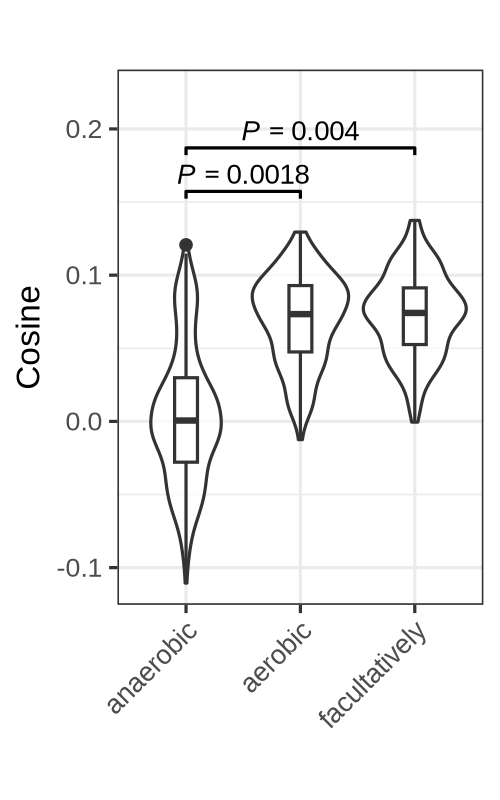

In [10]:
local({
  options(repr.plot.width = 2.5, repr.plot.height = 4, repr.plot.res = 200)
  print(p1)
})

### PLS-DA results

In [11]:
## ================================================================
## Helpers for the phylogenetic permutation results
##
## The analysis script now stores a plain list (not an opls S4 object)
## in data/<source>/phyloperm_<trait>.rds. Fields used here:
##   scores      data.frame with columns p1, p2 (rownames = taxon ids)
##   q2_obs, r2y_obs, pQ2_phylo, pR2Y_phylo, z_q2, n_sim_ok
## ================================================================
read_pp <- function(dir, trait) {
    f <- file.path(dir, paste0("phyloperm_", trait, ".rds"))
    if (!file.exists(f)) return(NULL)
    readRDS(f)
}

## Scatter data for one trait, coloured by the trait table
pp_scores <- function(dir, trait, traits_df, facet_label) {
    res <- read_pp(dir, trait)
    if (is.null(res)) return(NULL)
    d <- as.data.frame(res$scores)
    d$Trait <- traits_df[rownames(d), trait]
    d$facet_group <- facet_label
    d[!is.na(d$Trait), ]
}

## Annotation row for one trait
pp_annot <- function(dir, trait, facet_label) {
    res <- read_pp(dir, trait)
    if (is.null(res)) return(NULL)
    data.frame(R2Y_model  = res$r2y_obs,
               Q2Y_model  = res$q2_obs,
               pR2Y       = res$pR2Y_phylo,
               pQ2        = res$pQ2_phylo,
               z_q2       = res$z_q2,
               n_sim_ok   = res$n_sim_ok,
               facet_group = facet_label,
               stringsAsFactors = FALSE)
}

## One flat row per trait, for the R2 vs Q2 scatter
pp_summary <- function(dir, trait, label = trait) {
    res <- read_pp(dir, trait)
    if (is.null(res)) return(NULL)
    data.frame(Traits = label,
               R2Y    = res$r2y_obs,
               Q2     = res$q2_obs,
               pR2Y   = res$pR2Y_phylo,
               pQ2    = res$pQ2_phylo,
               z_q2   = res$z_q2,
               n_taxa = res$n_taxa,
               stringsAsFactors = FALSE)
}

## Shared annotation layers: R2/Q2 top-left, phylogenetic p values top-right
annot_layers <- function(annotation_data) {
    list(
        geom_text(data = annotation_data, inherit.aes = FALSE,
                  aes(x = -Inf, y = Inf, label = sprintf("R2=%.2g", R2Y_model)),
                  hjust = -0.05, vjust = 1.1, size = 3),
        geom_text(data = annotation_data, inherit.aes = FALSE,
                  aes(x = -Inf, y = Inf, label = sprintf("Q2=%.2g", Q2Y_model)),
                  hjust = -0.05, vjust = 3.1, size = 3),
        geom_text(data = annotation_data, inherit.aes = FALSE,
                  aes(x = Inf, y = Inf,
                      label = paste0("pR2=", pR2Y)),
                  hjust = 1.05, vjust = 1.1, size = 3),
        geom_text(data = annotation_data, inherit.aes = FALSE,
                  aes(x = Inf, y = Inf,
                      label = paste0("pQ2=", pQ2)),
                  hjust = 1.05, vjust = 3.1, size = 3)
    )
}

DIR_BUGBASE <- "data/bugbase"
DIR_TRAITAR <- "data/traitar"
DIR_BACDIVE <- "data/bacdive"

#### Q2 and R2 point plot

In [12]:
## ================================================================
## Class-size guard, replacing the old
##   sum(table(traits[rownames(model@scoreMN), i]) > 5) == 2
## The class counts are already stored in the result list, so the
## trait table does not need to be re-subset here.
## ================================================================
pp_class_ok <- function(dir, trait, min_per_class = 5, n_class = 2) {
    res <- read_pp(dir, trait)
    if (is.null(res)) return(FALSE)
    cls <- as.integer(res$class_n)
    length(cls) == n_class && min(cls) > min_per_class
}

## Collect several traits into one table; missing rds files are dropped
pp_summary_many <- function(dir, traits, labels = traits) {
    map2_dfr(traits, labels, ~pp_summary(dir, .x, label = .y))
}

## ================================================================
## Traitar - Growth: Sugar
## The rds file names follow the check.names = TRUE column names,
## so accessions still have to be mapped to the mangled names.
## ================================================================
traits_group <- read.csv("data/traits.tsv", sep = "\t", check.names = FALSE) %>%
    filter(category == "Growth: Sugar") %>%
    slice(-1)

names_1 <- read.csv("data/trait_predcit.csv", row.names = 1, check.names = FALSE) %>% colnames()
names_2 <- read.csv("data/trait_predcit.csv", row.names = 1) %>% colnames()
names_dict <- setNames(names_2, names_1)

traitar_traits <- unname(names_dict[traits_group$accession])
traitar_labels <- traits_group$accession

res_traitar <- pp_summary_many(DIR_TRAITAR, traitar_traits, traitar_labels) %>%
    filter(Traits != "Urea hydrolysis") %>%
    mutate(group_1 = "Traitar",
           group_2 = "growth: sugar")

In [13]:
## ================================================================
## BacDive - assimilation / builds_acid_from
## ================================================================
agg_bac <- read.csv("data/agg_bac.csv") %>%
    filter(level_2 %in% c("assimilation", "builds_acid_from"))
agg_bac <- agg_bac[!duplicated(agg_bac$terms), ] %>%
    filter(map_lgl(terms, ~pp_class_ok(DIR_BACDIVE, .x)))

res_bacdive <- pp_summary_many(DIR_BACDIVE, agg_bac$terms,
                               str_to_title(agg_bac$level_3)) %>%
    mutate(group_1 = "BacDive",
           group_2 = agg_bac$level_2[match(Traits, str_to_title(agg_bac$level_3))])

## ================================================================
## Combine, BH-FDR within source (same grouping as the analysis script).
## pQ2 is the primary criterion; pR2Y is secondary.
## Traits sitting on the resolution floor 1/(n_sim_ok + 1) are ranked
## by z_q2 instead of by p.
## ================================================================
results <- bind_rows(res_traitar, res_bacdive) %>%
    mutate(sig     = ifelse(pQ2 <= 0.05, "sig.", "ns"),
           group_1 = factor(group_1, levels = c("Traitar", "BacDive"))) %>%
    arrange(group_1, pQ2, desc(z_q2))

In [14]:
p_point <- results %>% ggplot(aes(x = R2Y, y = Q2)) +
    geom_point(aes(color = sig, shape = group_2)) +
    theme_bw() +
    labs(x = "R2", y = "Q2", shape = "", color = "") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.5) +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.5) +
    geom_text_repel(aes(label = Traits),
                    size = 2,
                    max.overlaps = Inf,
                    box.padding = 0.5,
                    min.segment.length = 0) +
    scale_color_manual(values = c("sig." = "#E41A1C", "ns" = "gray")) +
    facet_wrap(. ~ group_1, scales = "free", nrow = 2) +
    guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)),
           shape = guide_legend(override.aes = list(size = 3)))

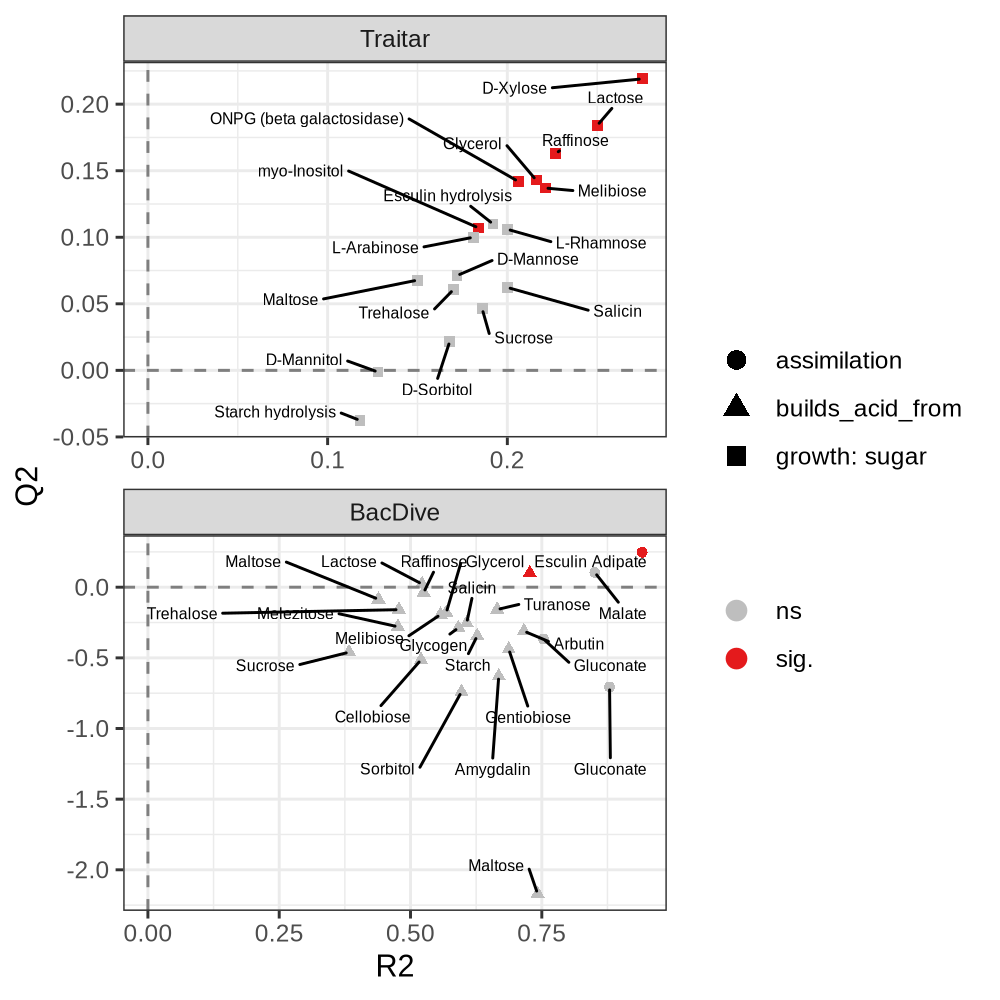

In [15]:
local({
  options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)
  print(p_point)
})

#### traits predict

In [16]:
brewer.pal(12, c("Set3"))

[1] "#8DD3C7" "#FFFFB3" "#BEBADA" "#FB8072" "#80B1D3" "#FDB462" "#B3DE69"
 [8] "#FCCDE5" "#D9D9D9" "#BC80BD" "#CCEBC5" "#FFED6F"

In [17]:
df_1 <- read.csv("data/auc_res.csv") %>%
    filter(datasize == "210,000") %>% filter(group == "times_1")
df_1 <- df_1[, c("auc", "embedding", "traits_type", "tax")]
colnames(df_1) <- c("AUC", "embedding", "traits", "tax")
df_1$group <- "traits_1"
df_2 <- read.csv("data/predict_metabolics_res.csv") %>%
    arrange(desc(AUC))
df_2$group <- "traits_2"

df <- rbind(df_1, df_2)

In [18]:
unique(df$traits)

[1] "Oxygen_Preference" "Gram_Status"       "Motility"         
 [4] "Spore_Formation"   "Lactose"           "Salicin"          
 [7] "Glycerol"          "Melibiose"         "Trehalose"        
[10] "Sorbitol"          "Maltose"           "Sucrose"

In [19]:
df_1 <- read.csv("data/auc_res.csv") %>%
    filter(datasize == "210,000") %>% filter(group == "times_1")
df_1 <- df_1[, c("auc", "embedding", "traits_type", "tax")]
colnames(df_1) <- c("AUC", "embedding", "traits", "tax")
df_1$group <- "traits_1"
df_2 <- read.csv("data/predict_metabolics_res.csv") %>%
    arrange(desc(AUC))
df_2$group <- "traits_2"

df <- rbind(df_1, df_2)
# df$traits <- factor(df$traits, levels = c("Oxygen_Preference", "Gram_Status", "Motility",
#                                           "Spore_Formation", "Lactose", "Melibiose", "Glycerol",
#                                           "Maltose", "Salicin", "Sucrose", "Trehalose"))

In [20]:
## ================================================================
## Figure 2C - trait prediction across embeddings
##
## Horizontal layout: the primary comparison (embedding) gets the colour
## channel, phylum is demoted to shape, and the trait-group split that
## used to be encoded by bar fill is now a background band. Trait names
## read horizontally, so 11 traits x 3 embeddings fit in ~9 x 7 cm.
## ================================================================
emb_levels <- c("social_niche", "dnabert2", "phylo_pca")
emb_labels <- c(social_niche = "SNE", dnabert2 = "DNABERT-2", phylo_pca = "PhyloE")
emb_colors <- c(social_niche = "#E41A1C", dnabert2 = "#377EB8", phylo_pca = "#4DAF4A")
tax_shapes <- c(Actinomycetota = 16, Bacillota = 17, Bacteroidota = 15)
dodge_w    <- 0.75

## sanity check: which embeddings actually exist in each trait group
print(table(df$group, df$embedding))

## Display order, top to bottom: cellular traits first, then sugars,
## each block sorted by mean SNE AUC.
display_order <- df %>%
    filter(embedding == "social_niche") %>%
    group_by(group, traits) %>%
    summarise(m = mean(AUC), .groups = "drop") %>%
    arrange(group, desc(m)) %>%
    pull(traits) %>% as.character()

## coord_flip() puts level 1 at the bottom, so store levels reversed
df <- df %>%
    mutate(traits    = factor(as.character(traits), levels = rev(display_order)),
           embedding = factor(embedding, levels = emb_levels))

df_summary <- df %>%
    group_by(traits, group, embedding) %>%
    summarise(AUC_mean = mean(AUC), AUC_sd = sd(AUC), .groups = "drop") %>%
    mutate(AUC_sd = ifelse(is.na(AUC_sd), 0, AUC_sd))   # single-phylum traits

## the sugar block sits at positions 1..n2 after the reversal
n2 <- df %>% filter(group == "traits_2") %>% pull(traits) %>% unique() %>% length()

pos_bar <- position_dodge(width = dodge_w)
pos_pt  <- position_jitterdodge(dodge.width  = dodge_w,
                                jitter.width = 0.12, jitter.height = 0)

p_optimized <- ggplot() +
    ## background band = metabolic (sugar) traits
    annotate("rect", xmin = 0.5, xmax = n2 + 0.5, ymin = -Inf, ymax = Inf,
             fill = "grey92", alpha = 0.7) +
    geom_hline(yintercept = 0.5, linetype = "dashed",
               colour = "grey45", linewidth = 0.4) +

    ## mean +/- sd across phyla
    geom_linerange(data = df_summary,
                   aes(x = traits, ymin = AUC_mean - AUC_sd, ymax = AUC_mean + AUC_sd,
                       colour = embedding, group = embedding),
                   position = pos_bar, linewidth = 0.5) +
    geom_point(data = df_summary,
               aes(x = traits, y = AUC_mean, colour = embedding, group = embedding),
               position = pos_bar, shape = 124, size = 3) +

    ## individual phyla
    geom_point(data = df,
               aes(x = traits, y = AUC, colour = embedding, shape = tax,
                   group = embedding),
               position = pos_pt, size = 1.4, alpha = 0.85) +

    coord_flip(ylim = c(0.3, 1.0)) +
    scale_colour_manual(values = emb_colors, labels = emb_labels, name = "Embedding") +
    scale_shape_manual(values = tax_shapes, name = "Phylum") +
    labs(x = NULL, y = "AUC", title = "") +
    theme_bw(base_size = 9) +
    theme(panel.grid.major.y = element_blank(),
          panel.grid.minor   = element_blank(),
          axis.text          = element_text(colour = "black"),
          legend.key.size    = grid::unit(0.4, "cm"),
          legend.position    = "right") +
    guides(colour = guide_legend(order = 1, override.aes = list(shape = 16, size = 2.2)),
           shape  = guide_legend(order = 2, override.aes = list(colour = "black", size = 2.2)))

          
           dnabert2 phylo_pca social_niche
  traits_1        7         7            7
  traits_2       21        21           21


In [21]:
n_traits <- nlevels(df$traits)
sep_pos  <- seq(1.5, n_traits - 0.5, by = 1)

p_optimized <- ggplot() +
    ## background band = metabolic (sugar) traits
    annotate("rect", xmin = 0.5, xmax = n2 + 0.5, ymin = -Inf, ymax = Inf,
             fill = "grey92", alpha = 0.7) +
    geom_vline(xintercept = sep_pos, linetype = "dotted",
               colour = "grey70", linewidth = 0.25) +
    geom_vline(xintercept = n2 + 0.5, linetype = "dashed",
               colour = "grey40", linewidth = 0.4) +
    geom_hline(yintercept = 0.5, linetype = "dashed",
               colour = "grey45", linewidth = 0.4) +
    ## mean +/- sd across phyla
    geom_linerange(data = df_summary,
                   aes(x = traits, ymin = AUC_mean - AUC_sd, ymax = AUC_mean + AUC_sd,
                       colour = embedding, group = embedding),
                   position = pos_bar, linewidth = 0.5) +
    geom_point(data = df_summary,
               aes(x = traits, y = AUC_mean, colour = embedding, group = embedding),
               position = pos_bar, shape = 124, size = 3) +
    ## individual phyla
    geom_point(data = df,
               aes(x = traits, y = AUC, colour = embedding, shape = tax,
                   group = embedding),
               position = pos_pt, size = 1.4, alpha = 0.85) +
    coord_flip(ylim = c(0.3, 1.0)) +
    scale_colour_manual(values = emb_colors, labels = emb_labels, name = "Embedding") +
    scale_shape_manual(values = tax_shapes, name = "Phylum") +
    labs(x = NULL, y = "AUC", title = "") +
    theme_bw(base_size = 9) +
    theme(panel.grid.major   = element_blank(),
          panel.grid.minor   = element_blank(),
          axis.text          = element_text(colour = "black"),
          legend.key.size    = grid::unit(0.4, "cm"),
          legend.position    = "right") +
    guides(colour = guide_legend(order = 1, override.aes = list(shape = 16, size = 2.2)),
           shape  = guide_legend(order = 2, override.aes = list(colour = "black", size = 2.2))) +
    annotate("rect", xmin = seq(0.5, n_traits - 0.5, by = 2),
             xmax = seq(1.5, n_traits + 0.5, by = 2),
             ymin = -Inf, ymax = Inf, fill = "grey95", alpha = 0.5)

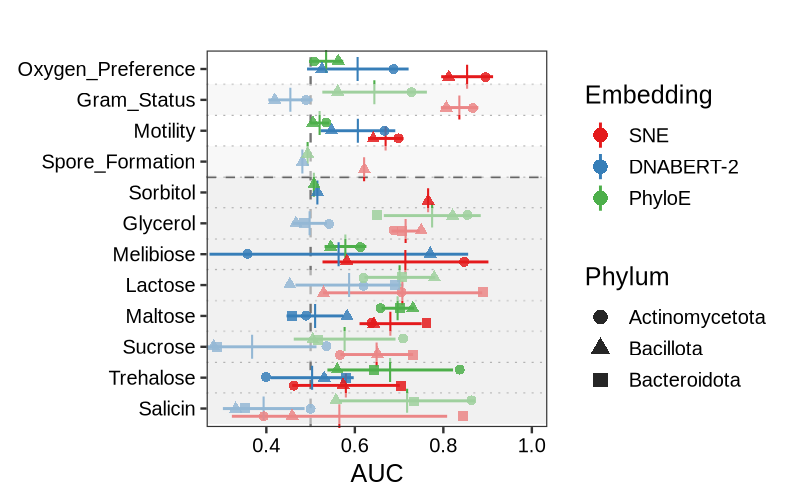

In [22]:
local({
  options(repr.plot.width = 4, repr.plot.height = 2.5, repr.plot.res = 200)
  print(p_optimized)
})

### pretrain data size of SNEs

In [23]:
auc_res <- read.csv("data/auc_res.csv")
auc_res <- auc_res %>% filter(embedding == "social_niche")
auc_res <- auc_res %>% group_by(traits_type, tax, datasize) %>%
    summarise(AUC = mean(auc), .groups = "drop")
auc_summary <- auc_res %>% group_by(traits_type, datasize) %>%
    summarise(AUC_mean = mean(AUC), .groups = "drop")
auc_res <- merge(auc_res, auc_summary, by = c("traits_type", "datasize"))
auc_res$datasize <- factor(auc_res$datasize,
                           levels = c("10,000", "20,000", "40,000", "80,000", "160,000", "210,000"))
auc_res <- auc_res %>% filter(datasize %in% c("80,000", "160,000", "210,000"))
auc_res$traits_type <- factor(auc_res$traits_type,
                              levels = c("Oxygen_Preference", "Gram_Status", "Motility", "Spore_Formation"))

## ================================================================
## Figure 2D - same encoding grammar as Fig. 2C:
##   colour = embedding (only SNE here, so fixed), shape = phylum.
## The shape scale is identical to 2C so patchwork can merge the two
## Phylum guides into a single legend when the figure is assembled.
## ================================================================
p_pretraining_data_size <- ggplot(auc_res, aes(x = datasize, y = AUC)) +
    geom_line(aes(group = 1, y = AUC_mean), linewidth = 0.6, colour = "grey25") +
    geom_point(aes(shape = tax), size = 1.8) + # colour = emb_colors[["social_niche"]]
    scale_shape_manual(values = tax_shapes, name = "Phylum") +
    facet_wrap(~ traits_type, nrow = 1) +
    coord_cartesian(ylim = c(0.45, 0.95)) +
    labs(x = NULL, y = "AUC") +
    theme_bw(base_size = 9) +
    theme(axis.text.x      = element_text(angle = 45, hjust = 1, vjust = 1, colour = "black"),
          axis.text.y      = element_text(colour = "black"),
          panel.grid.minor = element_blank(),
          strip.text       = element_text(size = 7.5))

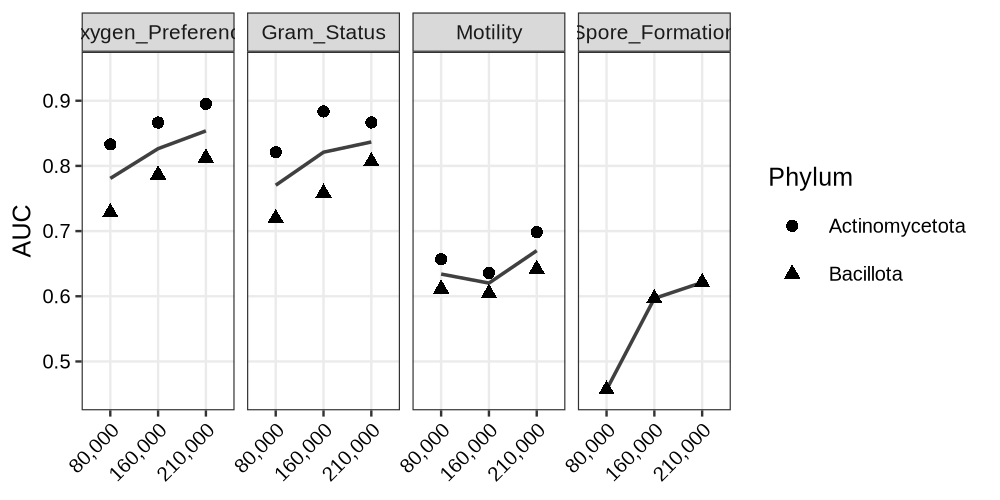

In [24]:
local({
  options(repr.plot.width = 5, repr.plot.height = 2.5, repr.plot.res = 200)
  print(p_pretraining_data_size)
})

### Figure 2 assembly

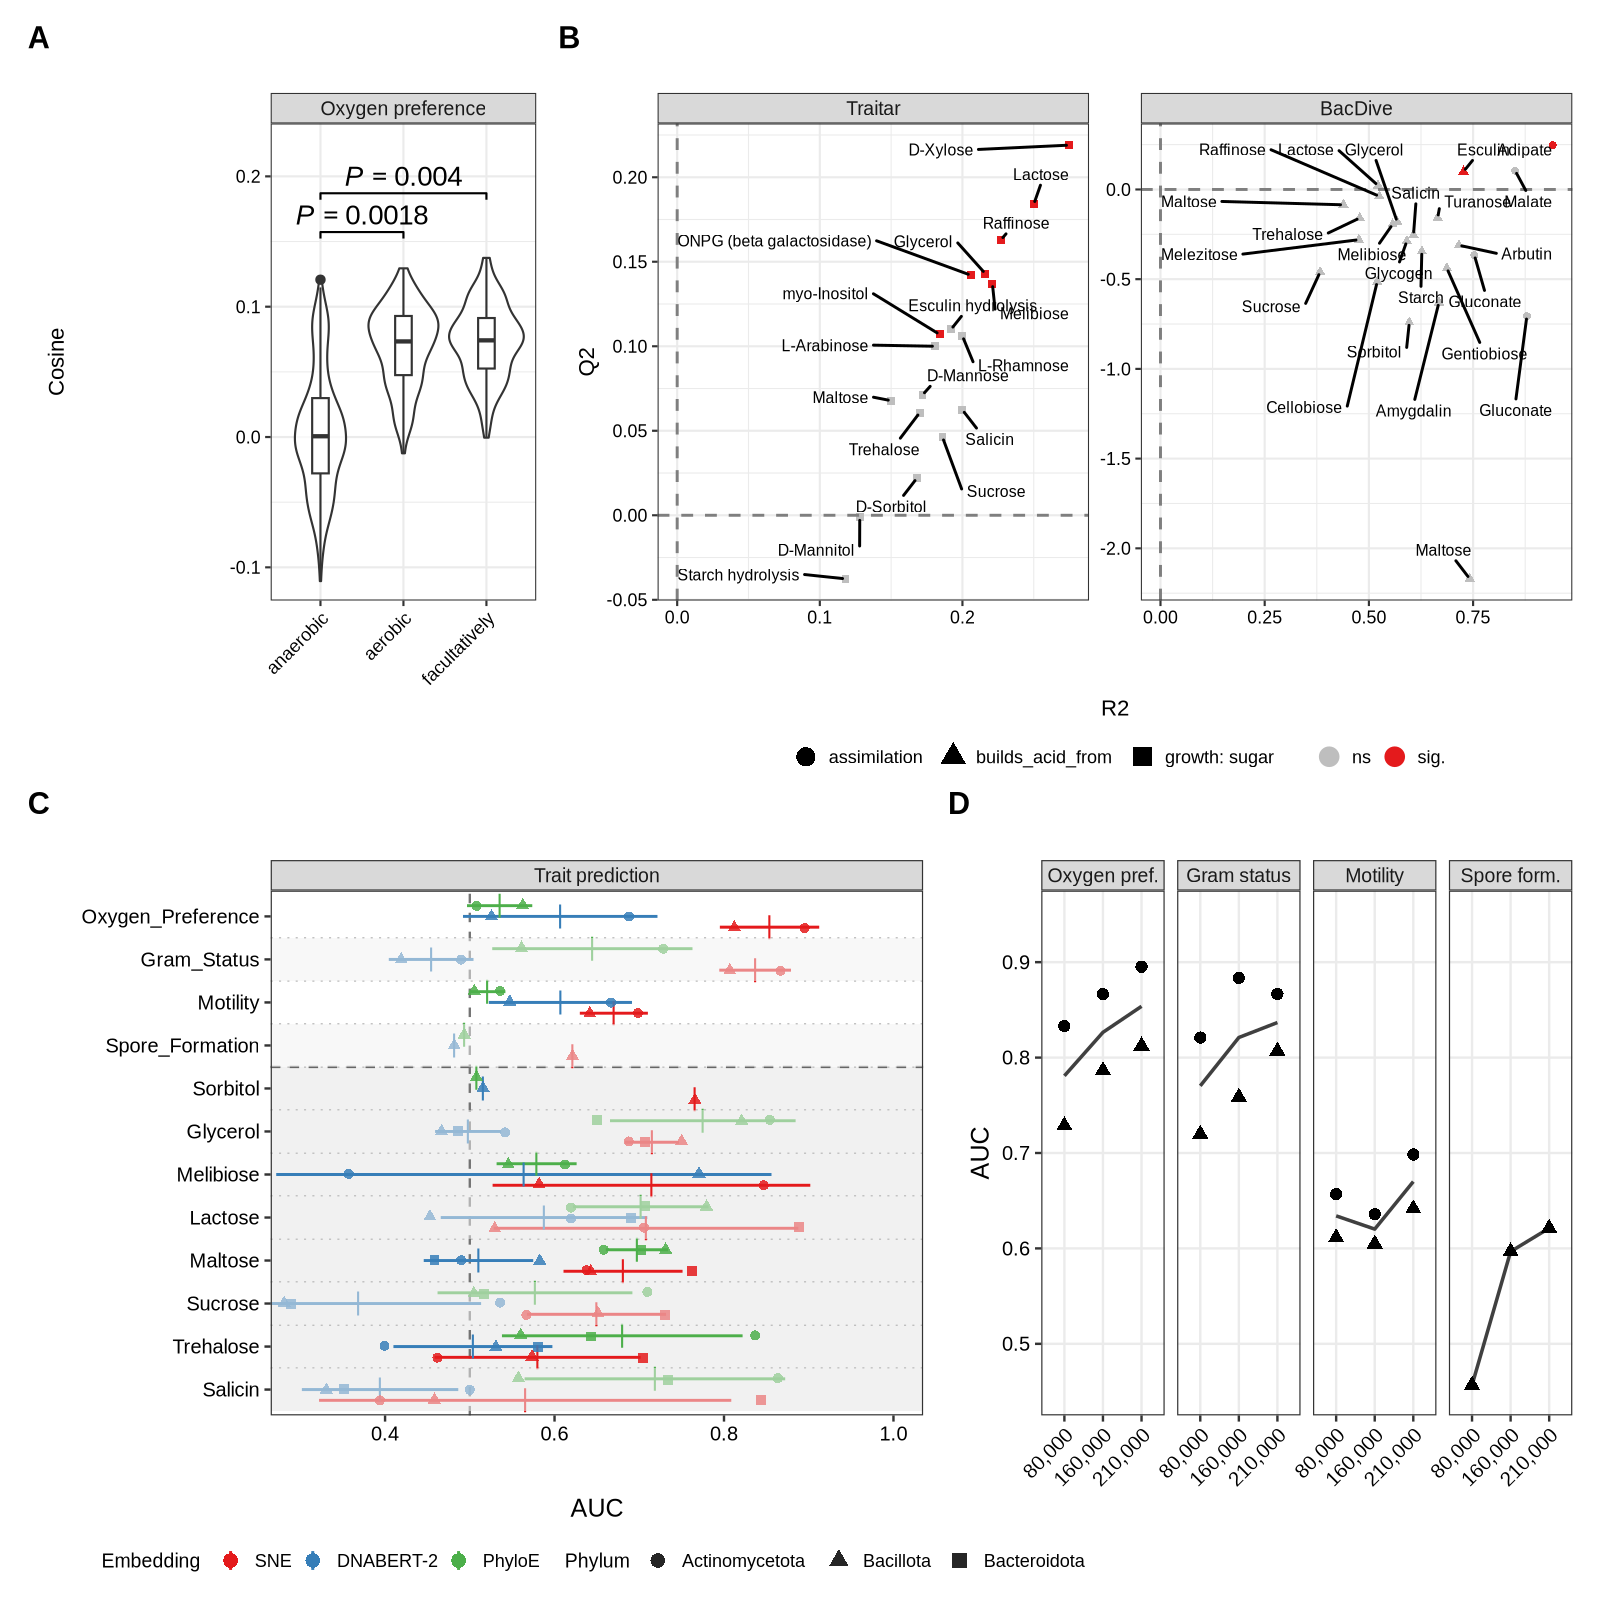

In [25]:
## ================================================================
## Figure 2 - four panels on ONE shared 8-column grid
##
##   AABBBBBB     A = 2/8   B = 6/8
##   CCCCDDDD     C = 4/8   D = 4/8
##
## Two things are needed to make the panel boxes line up.
##
## 1. A FLAT patchwork. All four plots go into a single plot_layout().
##    The nested form, (p_A + p_B) / (p_C + p_D), cannot align across
##    rows: each nested block becomes its own gtable and sizes its axis
##    gutter independently, so the A|B and C|D column boundaries landed
##    in different places even with matching width ratios.
##
## 2. A STRIP ON EVERY PANEL. patchwork aligns gtable rows, so the
##    panel rows of A and B already matched - but B carries an extra
##    facet-strip row above its panel and A did not, leaving B's grey
##    strip sticking out above A's frame. Giving A and C a single-facet
##    strip makes all four gtables structurally identical, so the outer
##    frames align too. D's strip labels are kept to one line so its
##    strip row is the same height as C's.
##
## Guides are deliberately NOT collected. guides = "collect" is what
## produced the duplicate Phylum legend: D draws its keys in a fixed
## red while C draws them in black, so patchwork saw two different
## guides and emitted both. Each plot keeps its own legend instead, and
## D's shape guide is dropped since C documents the same shape scale
## for the whole bottom row.
## ================================================================
library(patchwork)

p_point <- p_point + facet_wrap(. ~ group_1, scales = "free", nrow = 1)

legend_theme <- theme(legend.position = "bottom",
                      legend.box      = "horizontal",
                      legend.margin   = margin(t = 0, b = 0),
                      legend.title    = element_text(size = 7),
                      legend.text     = element_text(size = 6.5),
                      legend.key.size = grid::unit(0.3, "cm"))

strip_theme <- theme(strip.text = element_text(size = 7, margin = margin(2, 2, 2, 2)))

## A and C get a one-facet strip purely so their gtables match B and D.
## If your ggplot2 rejects a bare string on the RHS of facet_wrap, add a
## constant column to the data instead and facet on that.
p_A <- p1 + labs(tag = "A") + theme_bw(base_size = 8) +
    facet_wrap(~ "Oxygen preference") + strip_theme +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, colour = "black"),
          axis.text.y = element_text(colour = "black"))

p_B <- p_point + labs(tag = "B") + theme_bw(base_size = 8) + legend_theme +
    strip_theme +
    theme(axis.text = element_text(colour = "black"))

p_C <- p_optimized + labs(tag = "C") + legend_theme +
    facet_wrap(~ "Trait prediction") + strip_theme

## D: single-line strip labels, so its strip row matches C's, and no
##    Phylum legend of its own - C carries it for both bottom panels
facet_labs <- c(Oxygen_Preference = "Oxygen pref.",
                Gram_Status       = "Gram status",
                Motility          = "Motility",
                Spore_Formation   = "Spore form.")

p_D <- p_pretraining_data_size + labs(tag = "D") +
    facet_wrap(~ traits_type, nrow = 1,
               labeller = labeller(traits_type = facet_labs)) +
    guides(shape = "none") + strip_theme

design <- "
AABBBBBB
CCCCDDDD
"

fig2 <- p_A + p_B + p_C + p_D +
    plot_layout(design = design, heights = c(1, 1.1)) &
    theme(plot.tag = element_text(face = "bold", size = 11, hjust = 0, vjust = 1))

ggsave("results/Figure2.pdf", fig2, width = 18, height = 15, units = "cm")

local({
  options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)
  print(fig2)
})

#### Supplement plots

In [61]:
# Gram status, Oxygen preference, Cell shape, Spore production, Motility
### ================================================================
### bugbase
### ================================================================
traits <- read.csv("data/traits_bugbase.csv", row.names = 1)
traits_name <- c("Gram_Status", "Oxygen_Preference")
traits[traits == "Anaerobic"] <- "anaerobic"
traits[traits == "Aerobic"] <- "aerobic"
traits[traits == "Facultatively_Anaerobic"] <- "facultatively"
traits[traits == "Gram_Negative"] <- "negative"
traits[traits == "Gram_Positive"] <- "positive"

all_plot_data   <- map_dfr(traits_name, ~pp_scores(DIR_BUGBASE, .x, traits, .x))
annotation_data <- map_dfr(traits_name, ~pp_annot(DIR_BUGBASE, .x, .x))

p_bugbase <- all_plot_data %>%
    ggplot(aes(x = p1, y = p2, color = Trait)) +
    geom_point(size = 0.5, alpha = 0.5) +
    facet_wrap(~ facet_group, scales = "free", nrow = 2) +
    annot_layers(annotation_data) +
    theme_bw(base_size = 10) +
    scale_color_manual(values = combined_colors) +
    labs(x = "PLS_1", y = "PLS_2", title = "BugBase", color = "Traits") +
    theme(plot.title = element_text(hjust = 0.5, size = 10, face = "bold")) +
    guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)))

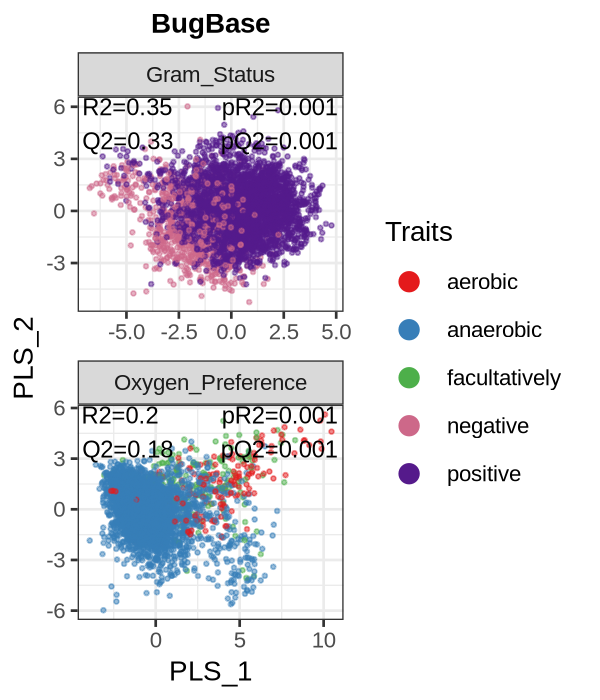

In [62]:
local({
  options(repr.plot.width = 3, repr.plot.height = 3.5, repr.plot.res = 200)
  print(p_bugbase)
})

In [63]:
### ================================================================
### traitar
### ================================================================
traits <- read.csv("data/trait_predcit.csv", row.names = 1)
traits[traits == 3] <- 1

## NOTE: labels below now match the analysis script. The previous version
## mapped Aerobe -> "anaerobic", Facultative -> "aerobic" and
## Anaerobe -> "facultatively", i.e. all three were shifted by one.
traits$Oxygen_Preference <- rep(NA_character_, nrow(traits))
traits[traits$Aerobe == 1, "Oxygen_Preference"] <- "aerobic"
traits[traits$Facultative == 1, "Oxygen_Preference"] <- "facultatively"
traits[traits$Anaerobe == 1, "Oxygen_Preference"] <- "anaerobic"
## same exclusion rule as the analysis script: ambiguous rows are dropped
traits[rowSums(traits[, c("Aerobe", "Facultative", "Anaerobe")]) != 1,
       "Oxygen_Preference"] <- NA

traits$`Gram_Status` <- rep(NA_character_, nrow(traits))
traits[traits$`Gram.negative` == 1, "Gram_Status"] <- "negative"
traits[traits$`Gram.positive` == 1, "Gram_Status"] <- "positive"
traits[rowSums(traits[, c("Gram.negative", "Gram.positive")]) != 1,
       "Gram_Status"] <- NA

traits$`cell_shape` <- rep(NA_character_, nrow(traits))
traits[traits$Coccus == 1, "cell_shape"] <- "coccus"
traits[traits$`Bacillus.or.coccobacillus` == 1, "cell_shape"] <- "bacillus or \ncoccobacillus"
traits[rowSums(traits[, c("Coccus", "Bacillus.or.coccobacillus")]) != 1,
       "cell_shape"] <- NA

## remaining binary columns: 0/1 -> no/yes, without touching the
## character columns constructed above
bin_cols <- setdiff(colnames(traits),
                    c("Oxygen_Preference", "Gram_Status", "cell_shape"))
traits[bin_cols] <- lapply(traits[bin_cols],
                           function(z) ifelse(is.na(z), NA,
                                       ifelse(z == 1, "yes", "no")))

traits_name <- c("Gram_Status", "Oxygen_Preference", "cell_shape",
                 "Spore.formation", "Motile")
traits_name_list <- list(Gram_Status       = "Gram_Status",
                         Oxygen_Preference = "Oxygen_Preference",
                         cell_shape        = "Cell_Shape",
                         Spore.formation   = "Spore_Formation",
                         Motile            = "Motility")

all_plot_data   <- map_dfr(traits_name,
                           ~pp_scores(DIR_TRAITAR, .x, traits, traits_name_list[[.x]]))
annotation_data <- map_dfr(traits_name,
                           ~pp_annot(DIR_TRAITAR, .x, traits_name_list[[.x]]))

all_plot_data$Trait <- factor(all_plot_data$Trait, levels = unique(all_plot_data$Trait))
all_plot_data$facet_group <- factor(all_plot_data$facet_group,
                                    levels = unlist(traits_name_list, use.names = FALSE))
annotation_data$facet_group <- factor(annotation_data$facet_group,
                                      levels = levels(all_plot_data$facet_group))

p_traitar <- all_plot_data %>%
    ggplot(aes(x = p1, y = p2, color = Trait)) +
    geom_point(size = 0.5, alpha = 0.5) +
    facet_wrap(~ facet_group, scales = "free", nrow = 5) +
    annot_layers(annotation_data) +
    theme_bw(base_size = 10) +
    scale_color_manual(values = combined_colors) +
    labs(x = "PLS_1", y = "PLS_2", title = "Traitar", color = "Traits") +
    theme(plot.title = element_text(hjust = 0.5, size = 10, face = "bold")) +
    guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)))

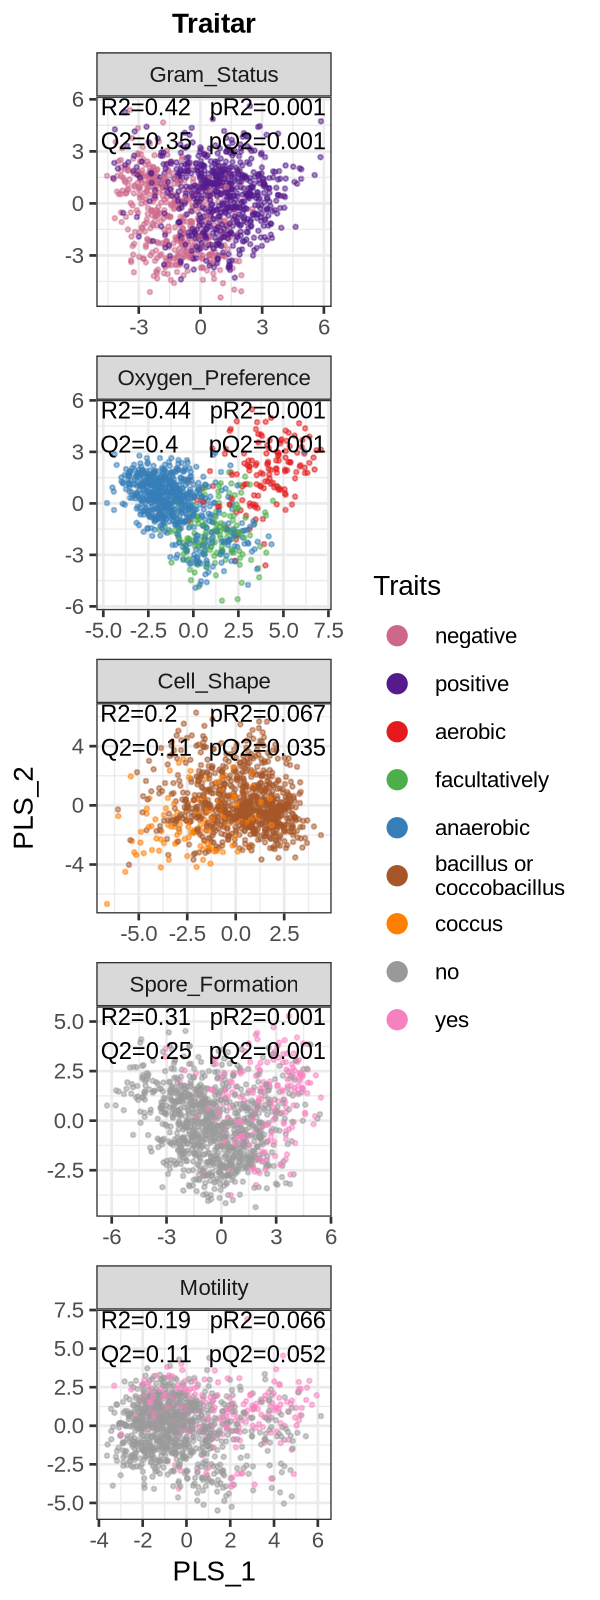

In [64]:
local({
  options(repr.plot.width = 3, repr.plot.height = 8, repr.plot.res = 200)
  print(p_traitar)
})

In [65]:
### ================================================================
### bacDive
### ================================================================
load_bacdive_traits <- function() {
    tr <- read.csv("data/bacDive.csv")
    tr <- tr[!duplicated(tr$X16s_ID), ]
    rownames(tr) <- tr$X16s_ID

    emb <- read.csv("../../data/social_niche_embedding_100.txt",
                    row.names = 1, sep = " ", header = FALSE)
    accessions_num <- str_split(rownames(emb), "\\.", simplify = TRUE)[, 1]
    d <- data.frame(accessions = accessions_num, embed_id = rownames(emb))
    inter_id <- intersect(rownames(tr), d$accessions)
    d <- d %>% filter(accessions %in% inter_id)
    tr <- tr[d$accessions, ]
    rownames(tr) <- d$embed_id

    tr$`Oxygen.Preference` <- rep(NA, nrow(tr))
    tr <- tr %>% mutate(Oxygen.Preference = case_when(aerobe == 1 ~ "aerobic", TRUE ~ Oxygen.Preference))
    tr <- tr %>% mutate(Oxygen.Preference = case_when(`facultative.anaerobe` == 1 ~ "facultatively", TRUE ~ Oxygen.Preference))
    tr <- tr %>% mutate(Oxygen.Preference = case_when(anaerobe == 1 ~ "anaerobic", TRUE ~ Oxygen.Preference))
    tr
}

traits <- load_bacdive_traits()
traits[traits == 0] <- "no"
traits[traits == 1] <- "yes"
traits[traits == "mixed"] <- NA
traits[traits == "negative;positive"] <- NA
traits[traits == "negative;variable"] <- NA
traits[traits == ""] <- NA
traits[traits == "filament-shaped"] <- NA
traits[traits == "coccus-shaped"] <- "coccus"
traits[traits == "rod-shaped"] <- "bacillus"

traits_name <- c("gram_stain", "Oxygen.Preference", "cell_shape",
                 "spore_formation", "motility")
traits <- traits[, traits_name]
traits <- traits %>%
    mutate(cell_shape = if_else(cell_shape %in% c("coccus", "bacillus"), cell_shape, NA))

traits_name_list <- list(gram_stain        = "Gram_Status",
                         Oxygen.Preference = "Oxygen_Preference",
                         cell_shape        = "Cell_Shape",
                         spore_formation   = "Spore_Formation",
                         motility          = "Motility")

all_plot_data   <- map_dfr(traits_name,
                           ~pp_scores(DIR_BACDIVE, .x, traits, traits_name_list[[.x]]))
annotation_data <- map_dfr(traits_name,
                           ~pp_annot(DIR_BACDIVE, .x, traits_name_list[[.x]]))

all_plot_data$Trait <- factor(all_plot_data$Trait, levels = unique(all_plot_data$Trait))
all_plot_data$facet_group <- factor(all_plot_data$facet_group,
                                    levels = unlist(traits_name_list, use.names = FALSE))
annotation_data$facet_group <- factor(annotation_data$facet_group,
                                      levels = levels(all_plot_data$facet_group))

p_bacdive <- all_plot_data %>%
    ggplot(aes(x = p1, y = p2, color = Trait)) +
    geom_point(size = 0.5, alpha = 0.5) +
    facet_wrap(~ facet_group, scales = "free", nrow = 5) +
    annot_layers(annotation_data) +
    theme_bw(base_size = 10) +
    scale_color_manual(values = combined_colors) +
    labs(x = "PLS_1", y = "PLS_2", title = "BacDive", color = "Traits") +
    theme(plot.title = element_text(hjust = 0.5, size = 10, face = "bold")) +
    guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)))

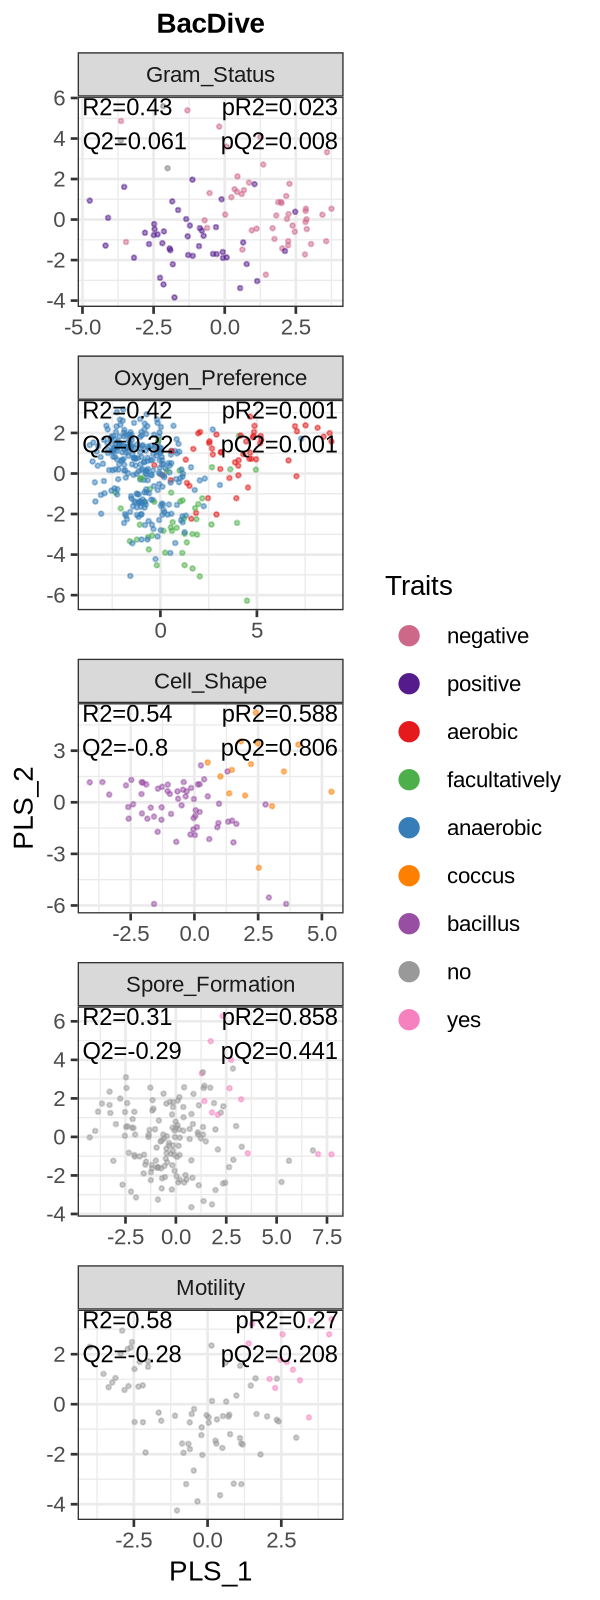

In [66]:
local({
  options(repr.plot.width = 3, repr.plot.height = 8, repr.plot.res = 200)
  print(p_bacdive)
})

In [67]:
## ================================================================
## Panel helpers
## ================================================================
## Scores + annotation for a set of traits, facetted in the given order.
## Traits whose rds file is missing are dropped from the facet levels.
pp_panel_data <- function(dir, traits, labels, traits_df) {
    scores <- map2_dfr(traits, labels, ~pp_scores(dir, .x, traits_df, .y))
    annot  <- map2_dfr(traits, labels, ~pp_annot(dir, .x, .y))
    keep   <- labels[labels %in% annot$facet_group]
    annot  <- annot %>%
        mutate(pR2Y        = pR2Y,
               pQ2         = pQ2,
               facet_group = factor(facet_group, levels = keep))
    scores <- scores %>%
        mutate(Trait       = factor(Trait),
               facet_group = factor(facet_group, levels = keep))
    list(scores = scores, annot = annot)
}

pp_panel_plot <- function(pd, ncol, title) {
    ggplot(pd$scores, aes(x = p1, y = p2, color = Trait)) +
        geom_point(size = 1, alpha = 0.5) +
        facet_wrap(~ facet_group, ncol = ncol, scales = "free") +
        annot_layers(pd$annot) +
        theme_bw(base_size = 10) +
        labs(color = NULL, x = "PLS_1", y = "PLS_2", title = title) +
        theme(text = element_text(face = "bold"),
              plot.title = element_text(size = 14, face = "bold")) +
        guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)))
}

In [68]:
## ================================================================
## a. Traitar - growth: sugar
## The rds files are named after the check.names = TRUE column names,
## so the trait table is read the same way and accessions are mapped.
##
## NOTE: the result is bound to p_sugar, not p_traitar. p_traitar is
## already taken by the Traitar cellular-trait panel above; reusing the
## name here silently destroyed that object, so the Extended Data Fig. 5
## assembly had nothing left to draw for panel B.
## ================================================================
names_1 <- read.csv("data/trait_predcit.csv", row.names = 1, check.names = FALSE) %>% colnames()
names_2 <- read.csv("data/trait_predcit.csv", row.names = 1) %>% colnames()
names_dict <- setNames(names_2, names_1)

traits_group <- read.csv("data/traits.tsv", sep = "\t", check.names = FALSE) %>%
    filter(category == "Growth: Sugar") %>%
    slice(-1) %>%
    filter(accession != "Urea hydrolysis")

traits_traitar <- read.csv("data/trait_predcit.csv", row.names = 1)
traits_traitar[traits_traitar == 0] <- "no"
traits_traitar[traits_traitar == 1] <- "yes"
traits_traitar[traits_traitar == 3] <- "yes"

## Order the panels by observed Q2, as in the old arrange(desc(Q2))
ord_traitar <- pp_summary_many(DIR_TRAITAR,
                               unname(names_dict[traits_group$accession]),
                               traits_group$accession) %>%
    arrange(desc(Q2))

p_sugar <- pp_panel_data(DIR_TRAITAR,
                            unname(names_dict[ord_traitar$Traits]),
                            ord_traitar$Traits,
                            traits_traitar)

p_sugar <- pp_panel_plot(p_sugar, ncol = 5, title = "Traitar: growth sugar")

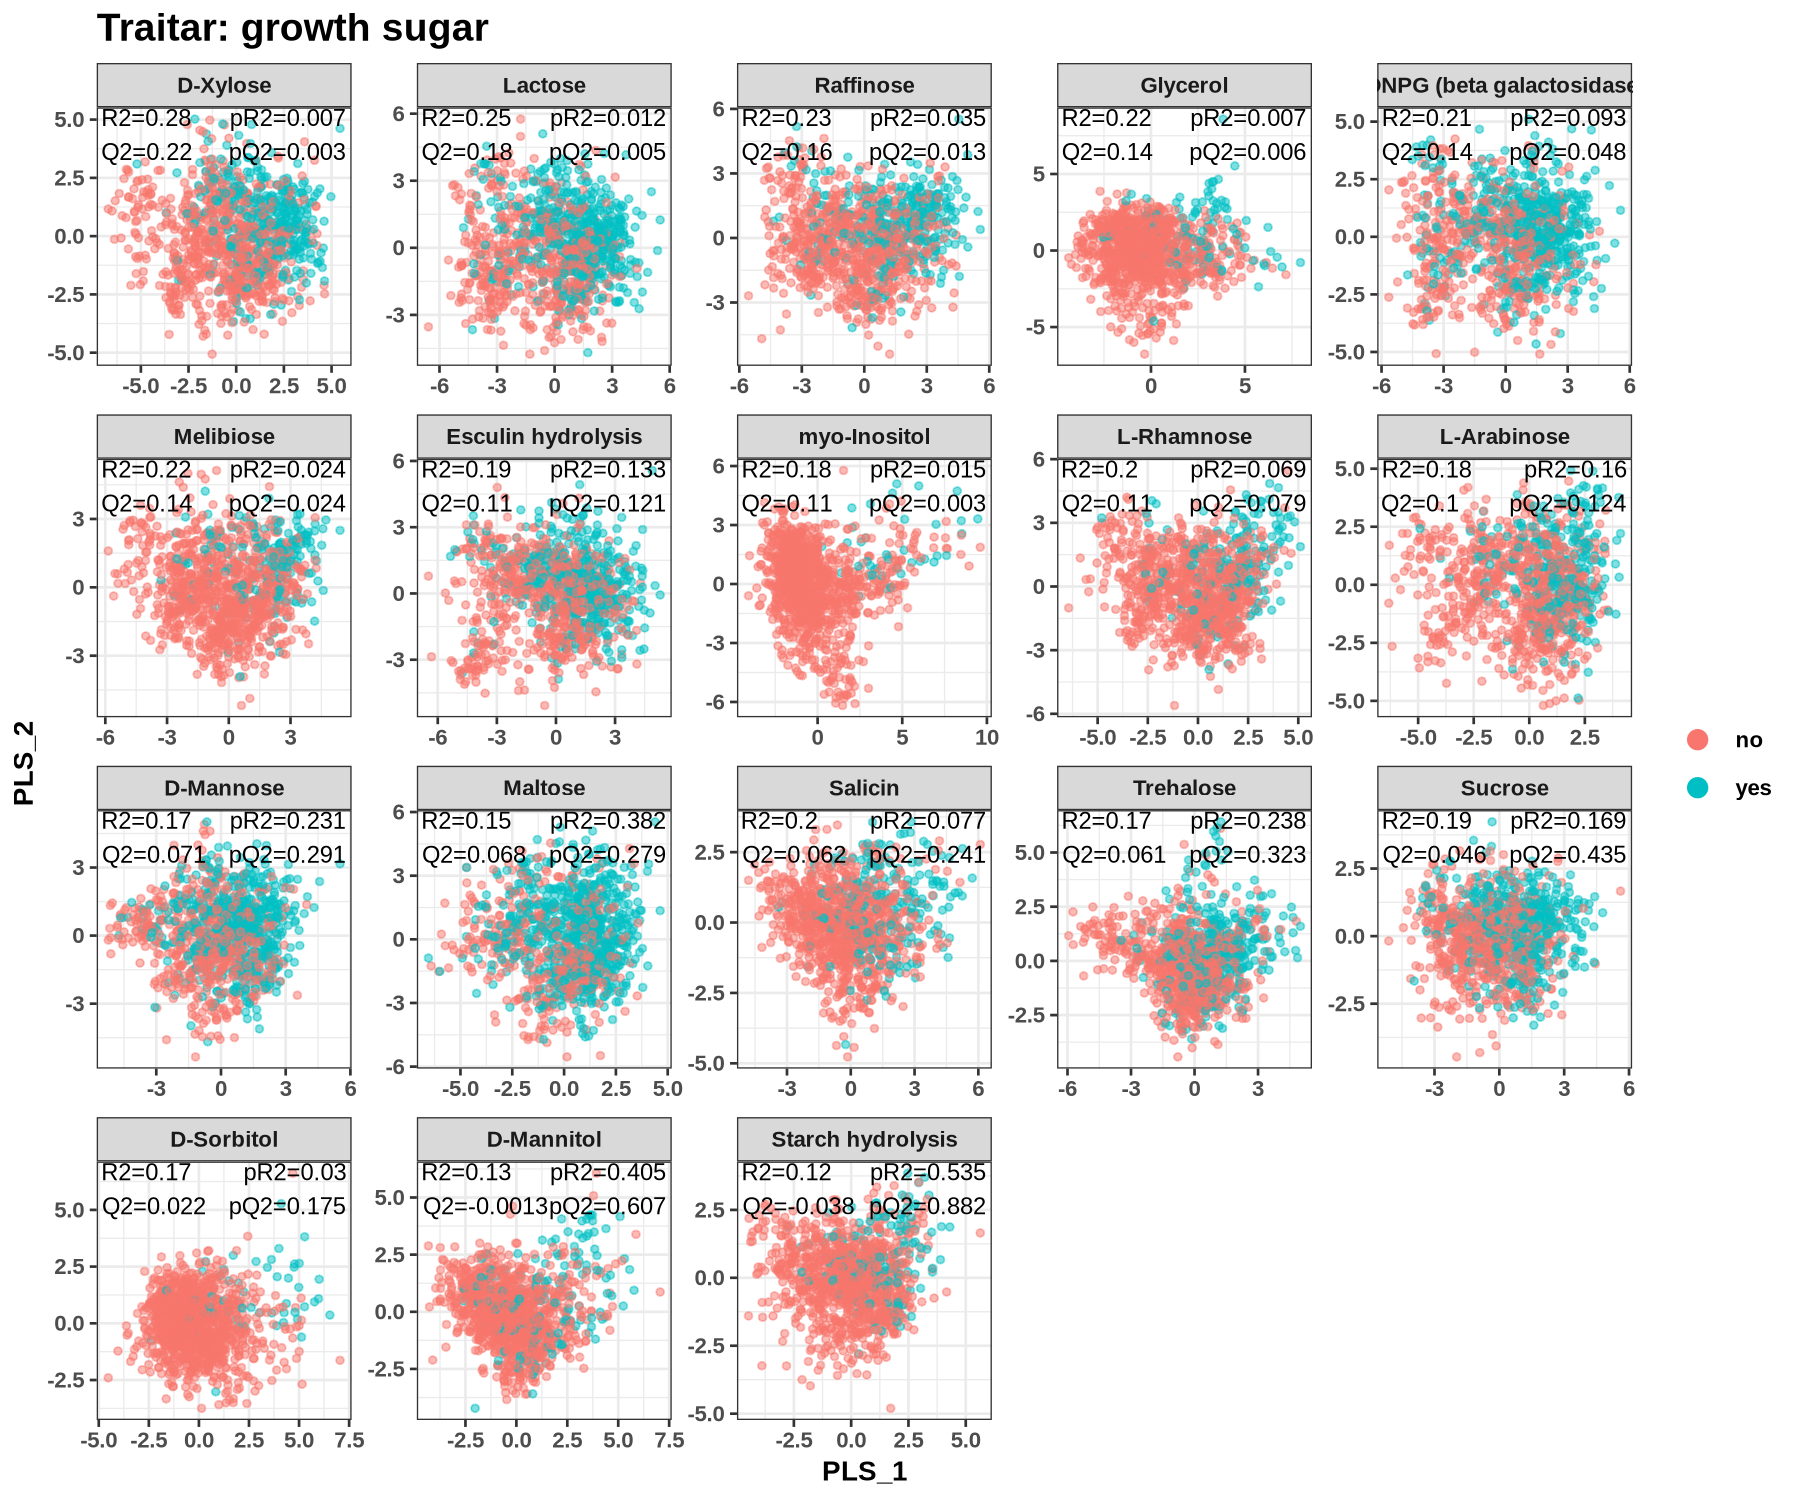

In [69]:
local({
  options(repr.plot.width = 9, repr.plot.height = 7.5, repr.plot.res = 200)
  print(p_sugar)
})

In [70]:
## ================================================================
## BacDive - trait table rebuilt exactly as in the analysis script,
## so the point colours match the labels the models were fitted on
## ================================================================
traits <- read.csv("data/bacDive.csv")
traits <- traits[!duplicated(traits$`X16s_ID`), ]
rownames(traits) <- traits$`X16s_ID`

co_embedding <- read.csv("../../data/social_niche_embedding_100.txt",
                         row.names = 1, sep = " ", header = FALSE)
accessions_num <- str_split(rownames(co_embedding), "\\.", simplify = TRUE)[, 1]
df <- data.frame(accessions = accessions_num, embed_id = rownames(co_embedding))
df <- df %>% filter(accessions %in% intersect(rownames(traits), df$accessions))
traits <- traits[df$accessions, ]
rownames(traits) <- df$embed_id

traits[traits == "NA"]   <- NA
traits[traits == "-"]    <- "no"
traits[traits == "+"]    <- "yes"
traits[traits == ""]     <- NA
traits[traits == "+;NA"] <- NA
traits[traits == 0]      <- "no"
traits[traits == 1]      <- "yes"
traits[traits == "no;yes"] <- NA

In [71]:
## ================================================================
## b / c. BacDive - assimilation and builds_acid_from
## pp_class_ok replaces the old sum(table(...) > 5) == 2 guard and the
## tryCatch that padded failures with zeros.
## ================================================================
agg_bac <- read.csv("data/agg_bac.csv") %>%
    filter(level_2 %in% c("assimilation", "builds_acid_from"))
agg_bac <- agg_bac[!duplicated(agg_bac$terms), ] %>%
    filter(terms %in% colnames(traits)) %>%
    filter(map_lgl(terms, ~pp_class_ok(DIR_BACDIVE, .x)))

q2_bac <- pp_summary_many(DIR_BACDIVE, agg_bac$terms, agg_bac$terms) %>%
    select(terms = Traits, Q2)

agg_bac <- agg_bac %>%
    left_join(q2_bac, by = "terms") %>%
    mutate(name = str_to_title(level_3)) %>%
    arrange(level_2, desc(Q2))

plot_bacdive_group <- function(level, ncol, title, file, width, height) {
    sub <- agg_bac %>% filter(level_2 == level)
    if (!nrow(sub)) return(invisible(NULL))
    pd <- pp_panel_data(DIR_BACDIVE, sub$terms, sub$name, traits)
    p  <- pp_panel_plot(pd, ncol = ncol, title = title)
    p
}

p_assim <- plot_bacdive_group("assimilation", ncol = 4,
                              title = "b BacDive: assimilation",
                              file  = "bac_dive_assimilation.pdf",
                              width = 27, height = 6)

p_acid <- plot_bacdive_group("builds_acid_from", ncol = 5,
                             title = "c BacDive: builds acid from",
                             file  = "bac_dive_builds_acid_from.pdf",
                             width = 35, height = 20)

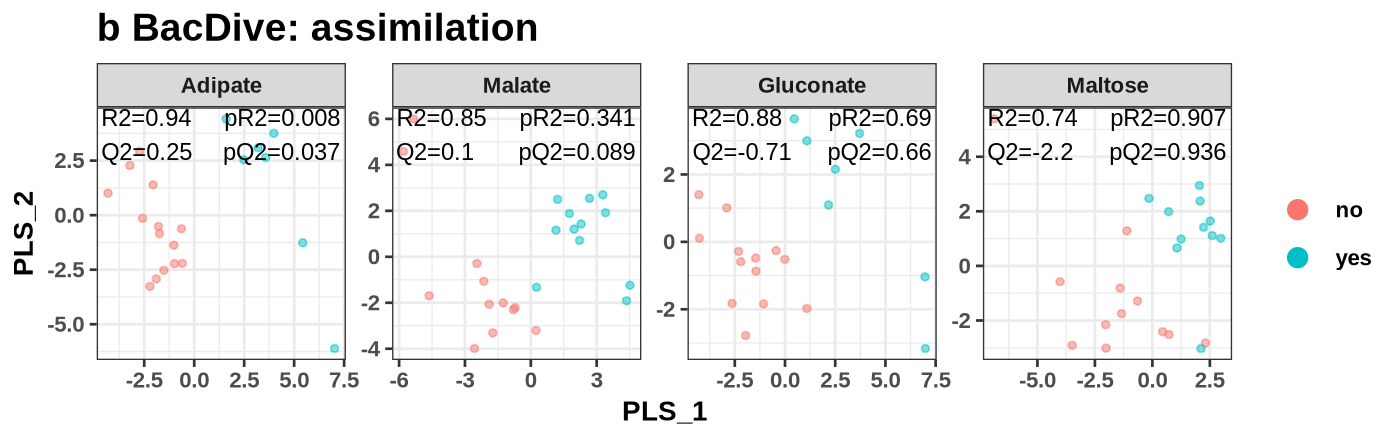

In [72]:
local({
  options(repr.plot.width = 7, repr.plot.height = 2.2, repr.plot.res = 200)
  print(p_assim)
})

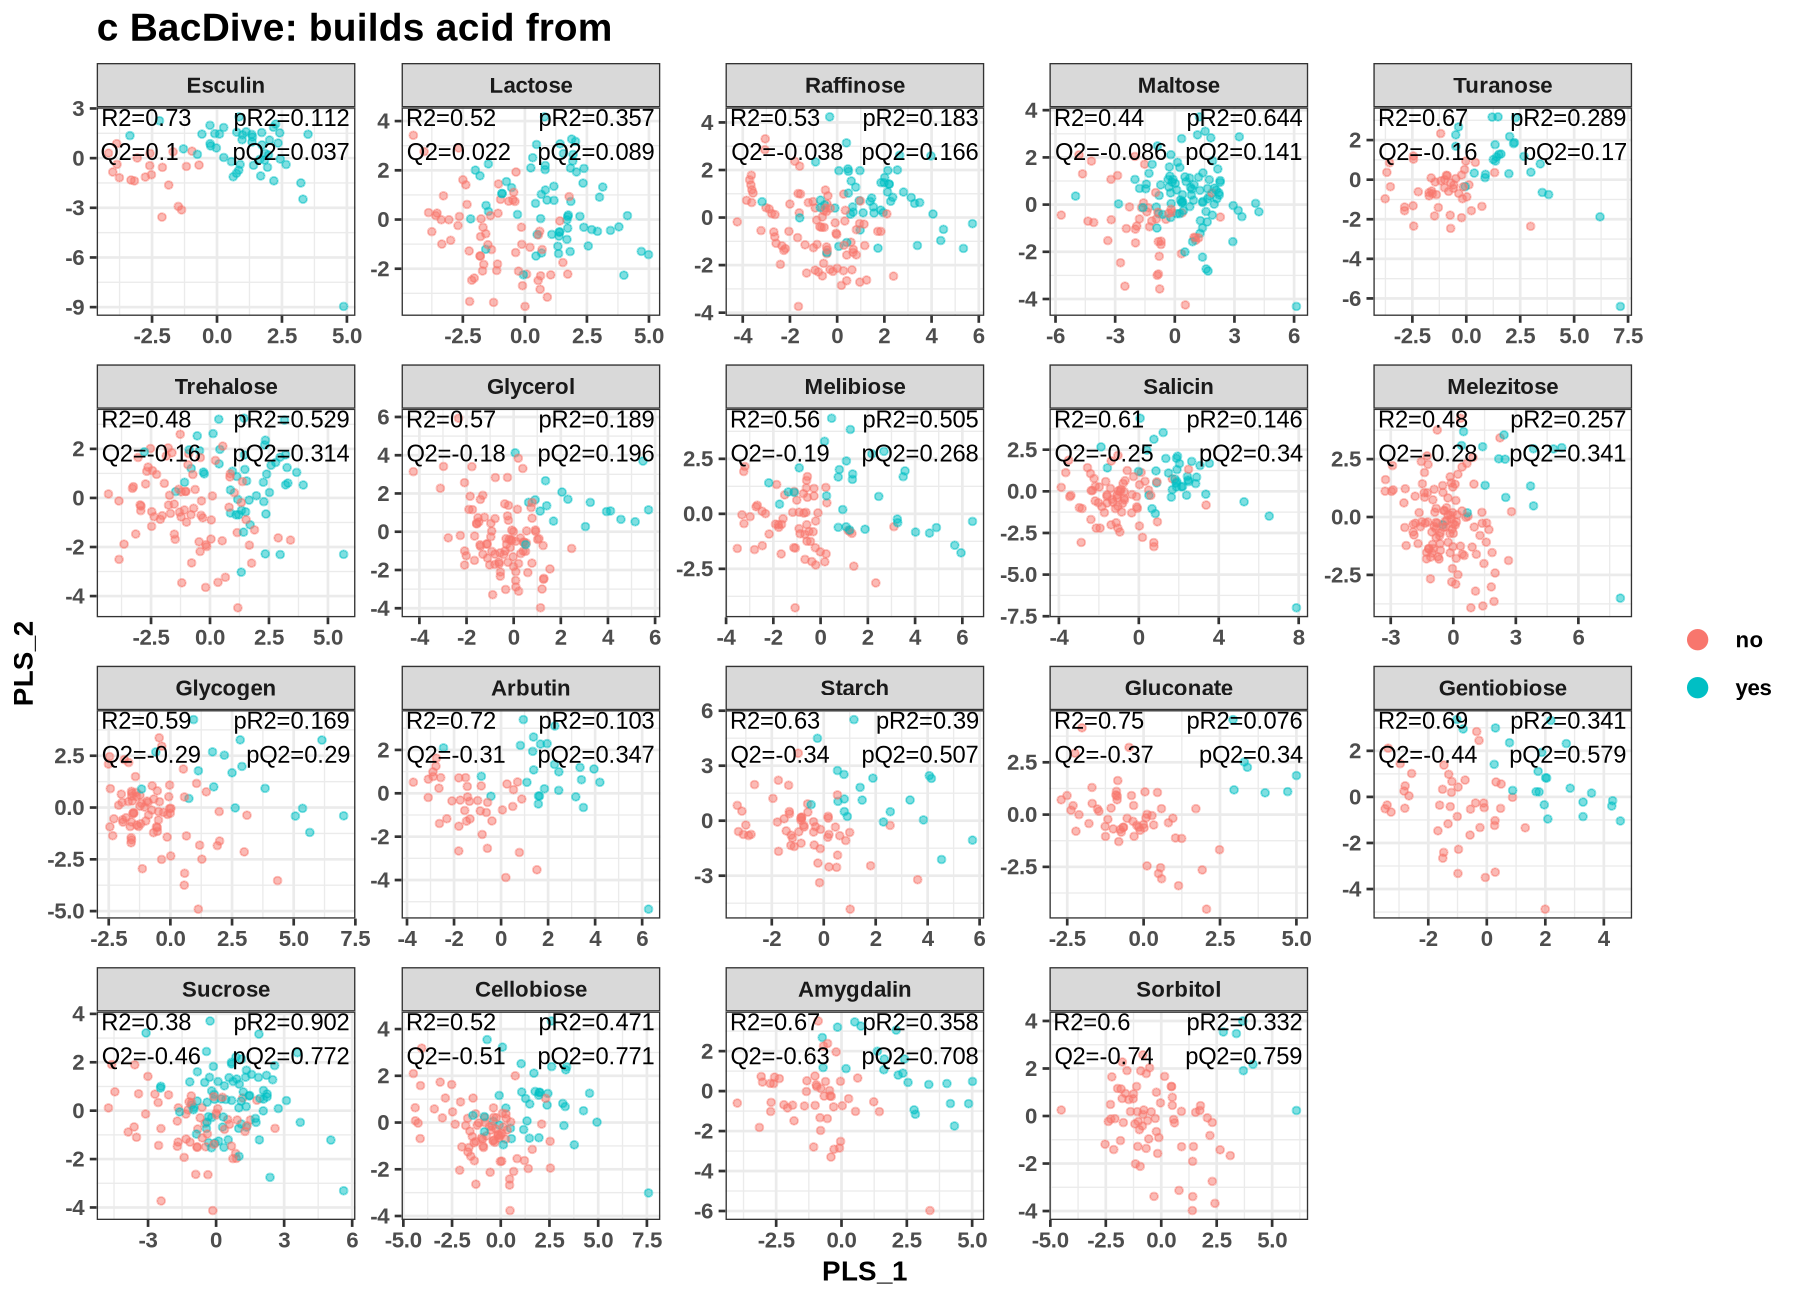

In [73]:
local({
  options(repr.plot.width = 9, repr.plot.height = 6.5, repr.plot.res = 200)
  print(p_acid)
})

### Extended Data Fig. 5 assembly

In [79]:
## ================================================================
## Extended Data Fig. 5, split into two sheets because six panels do
## not fit on one page:
##
##   part 1   A BugBase | B Traitar | C BacDive   (cellular traits)
##            D Traitar: growth sugar
##   part 2   E BacDive: assimilation
##            F BacDive: builds acid from
##
## Every facet on both sheets is drawn at the SAME physical size
## (PANEL_W x PANEL_H). Relative patchwork widths cannot do that: each
## panel keeps its own axis labels, and a cell of equal width therefore
## leaves a different amount of room for the plotting area. So each
## panel is turned into a gtable whose panel cells are set to a fixed
## size (fix_panel_size), and patchwork only places those blocks.
##
## The blocks are then padded to a common width, and to a common
## distance from the sheet edge to their first facet (align_blocks), so
## A - which has two facets where B-D have five - lines up with the rows
## below it instead of being centred over its own cell. Row heights and
## the sheet size are read back off the blocks, so nothing is stretched
## or cropped.
##
## Legends are NOT collected: C alone draws the shared trait legend,
## under its own panels. That costs C no height, because the panels are
## a fixed size. Fixing `limits` to the full combined_colors set is what
## makes C's single legend cover every level appearing in A and B too.
## ================================================================
library(patchwork)
library(grid)
library(gtable)

## ---- one size for every facet on both sheets ----
## PANEL_W is wide enough that the left-anchored R2/Q2 and the
## right-anchored pR2/pQ2 annotations do not run into each other.
## PANEL_H is not set by hand: sheet A-D has to fit on one page, so the
## facet height is solved for from SHEET1_H below, and sheet E-F then
## reuses it so that a facet is the same size on both sheets.
PANEL_W  <- unit(3.0, "cm")
SHEET1_H <- 12 * 2.54      # cm; A-D must fit a single page (12 in)
ANNOT_SIZE <- 2.5          # R2/Q2/pR2/pQ2 text

## patchwork surrounds each placed block with its own margin, so the
## sheet needs that much more room than the blocks themselves.
BLOCK_PAD <- 0.4   # cm per block, in each direction

## Set every panel cell of a ggplot to a fixed size. Returns a gtable,
## so the surrounding patchwork cell no longer stretches the plotting
## area to fill whatever width is left over.
fix_panel_size <- function(p, h, w = PANEL_W) {
    g <- ggplotGrob(p)
    panels <- g$layout[grepl("^panel", g$layout$name), ]
    g$widths[unique(panels$l)]  <- w
    g$heights[unique(panels$t)] <- h
    g
}

## Sizes of a finished block, in cm: total, and the strip down the left
## (tag, axis title, axis labels) that sits before the first facet.
g_width  <- function(g) convertWidth(sum(g$widths),   "cm", valueOnly = TRUE)
g_height <- function(g) convertHeight(sum(g$heights), "cm", valueOnly = TRUE)
g_left   <- function(g) {
    first <- min(g$layout$l[grepl("^panel", g$layout$name)])
    convertWidth(sum(g$widths[seq_len(first - 1)]), "cm", valueOnly = TRUE)
}

## Pad every block on the left so all first facets start at the same x,
## and on the right so all blocks are equally wide - patchwork centres
## what it places, so equal widths are what keeps the rows aligned.
align_blocks <- function(blocks) {
    left  <- vapply(blocks, g_left,  numeric(1))
    total <- vapply(blocks, g_width, numeric(1))
    target_left  <- max(left)
    target_total <- max(total - left) + target_left
    Map(function(g, l, w) {
        if (target_left - l > 1e-6)
            g <- gtable_add_cols(g, unit(target_left - l, "cm"), pos = 0)
        rest <- target_total - (target_left + w - l)
        if (rest > 1e-6) g <- gtable_add_cols(g, unit(rest, "cm"))
        g
    }, blocks, left, total)
}

## Blocks stacked in one column, and the sheet height that needs.
build_blocks <- function(plots, h) align_blocks(lapply(plots, fix_panel_size, h = h))
sheet_h <- function(blocks) sum(vapply(blocks, g_height, numeric(1))) +
                            2 * BLOCK_PAD * length(blocks)
sheet_w <- function(blocks) max(vapply(blocks, g_width, numeric(1))) + 2 * BLOCK_PAD
n_rows  <- function(blocks) sum(vapply(blocks, function(g)
    length(unique(g$layout$t[grepl("^panel", g$layout$name)])), numeric(1)))

## Facet height that makes a stack come out at `target` cm tall. Titles,
## strips and axes do not scale with the panels, so measuring one trial
## height is enough to solve for the right one.
solve_panel_height <- function(plots, target, trial = unit(2.8, "cm")) {
    blocks   <- build_blocks(plots, trial)
    rows     <- n_rows(blocks)
    overhead <- sheet_h(blocks) - rows * convertHeight(trial, "cm", valueOnly = TRUE)
    h <- (target - overhead) / rows
    if (h < 1) stop("target sheet height leaves no room for the panels")
    unit(h, "cm")
}

## The R2/Q2/pR2/pQ2 labels are geom_text layers baked into the panel
## builders; resize them here rather than re-running the analysis.
set_annot_size <- function(p, size = ANNOT_SIZE) {
    for (i in seq_along(p$layers))
        if (inherits(p$layers[[i]]$geom, "GeomText"))
            p$layers[[i]]$aes_params$size <- size
    p
}

## Long trait names (e.g. "ONPG (beta galactosidase)") are wider than a
## facet and would otherwise run off the sheet, so strip labels wrap.
## The facet is rebuilt with the ncol the panel was built with.
wrap_strips <- function(p, width = 18) {
    p + facet_wrap(~ facet_group, ncol = p$facet$params$ncol,
                   scales = "free", labeller = label_wrap_gen(width = width))
}

cell_traits <- list(
    facet_wrap(~ facet_group, scales = "free", nrow = 1,
               labeller = label_wrap_gen(width = 18)),
    scale_color_manual(values = combined_colors,
                       limits = names(combined_colors),
                       drop = FALSE, name = NULL)
)

s5_theme <- theme_bw(base_size = 8) +
    theme(strip.text       = element_text(size = 7, margin = margin(2, 2, 2, 2)),
          axis.text        = element_text(size = 6, colour = "black"),
          axis.title       = element_text(size = 7),
          panel.grid.minor = element_blank(),
          plot.title       = element_text(size = 8, face = "bold", hjust = 0),
          legend.title     = element_text(size = 7),
          legend.text      = element_text(size = 6.5),
          legend.key.size  = grid::unit(0.3, "cm"),
          plot.tag         = element_text(face = "bold", size = 11,
                                          hjust = 0, vjust = 1))

legend_bottom <- theme(legend.position = "bottom",
                       legend.box      = "horizontal",
                       legend.margin   = margin(t = 2, b = 0))

## ---------------- part 1: A-D ----------------
p_S5A <- set_annot_size(p_bugbase) + labs(tag = "A", title = "BugBase") +
    cell_traits + s5_theme + guides(color = "none")
p_S5B <- set_annot_size(p_traitar) + labs(tag = "B", title = "Traitar") +
    cell_traits + s5_theme + guides(color = "none")
p_S5C <- set_annot_size(p_bacdive) + labs(tag = "C", title = "BacDive") +
    cell_traits + s5_theme + legend_bottom + guides(color = guide_legend(nrow = 2))
p_S5D <- wrap_strips(set_annot_size(p_sugar)) +
    labs(tag = "D", title = "Traitar: growth sugar") + s5_theme +
    guides(color = "none")

plots_1  <- list(p_S5A, p_S5B, p_S5C, p_S5D)
PANEL_H  <- solve_panel_height(plots_1, SHEET1_H)   # also used by sheet E-F
blocks_1 <- build_blocks(plots_1, PANEL_H)

figS5_1 <- wrap_plots(lapply(blocks_1, function(g) wrap_elements(full = g)),
                      ncol = 1,
                      heights = unit(vapply(blocks_1, g_height, numeric(1)), "cm"))

ggsave("results/ExtendedDataFig5_AD.pdf", figS5_1, limitsize = FALSE, units = "cm",
       width = sheet_w(blocks_1), height = sheet_h(blocks_1))

## ---------------- part 2: E-F ----------------
p_S5E <- wrap_strips(set_annot_size(p_assim)) +
    labs(tag = "E", title = "BacDive: assimilation") + s5_theme +
    guides(color = "none")
p_S5F <- wrap_strips(set_annot_size(p_acid)) +
    labs(tag = "F", title = "BacDive: builds acid from") + s5_theme +
    legend_bottom + guides(color = guide_legend(nrow = 1))

blocks_2 <- build_blocks(list(p_S5E, p_S5F), PANEL_H)

figS5_2 <- wrap_plots(lapply(blocks_2, function(g) wrap_elements(full = g)),
                      ncol = 1,
                      heights = unit(vapply(blocks_2, g_height, numeric(1)), "cm"))

ggsave("results/ExtendedDataFig5_EF.pdf", figS5_2, limitsize = FALSE, units = "cm",
       width = sheet_w(blocks_2), height = sheet_h(blocks_2))


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


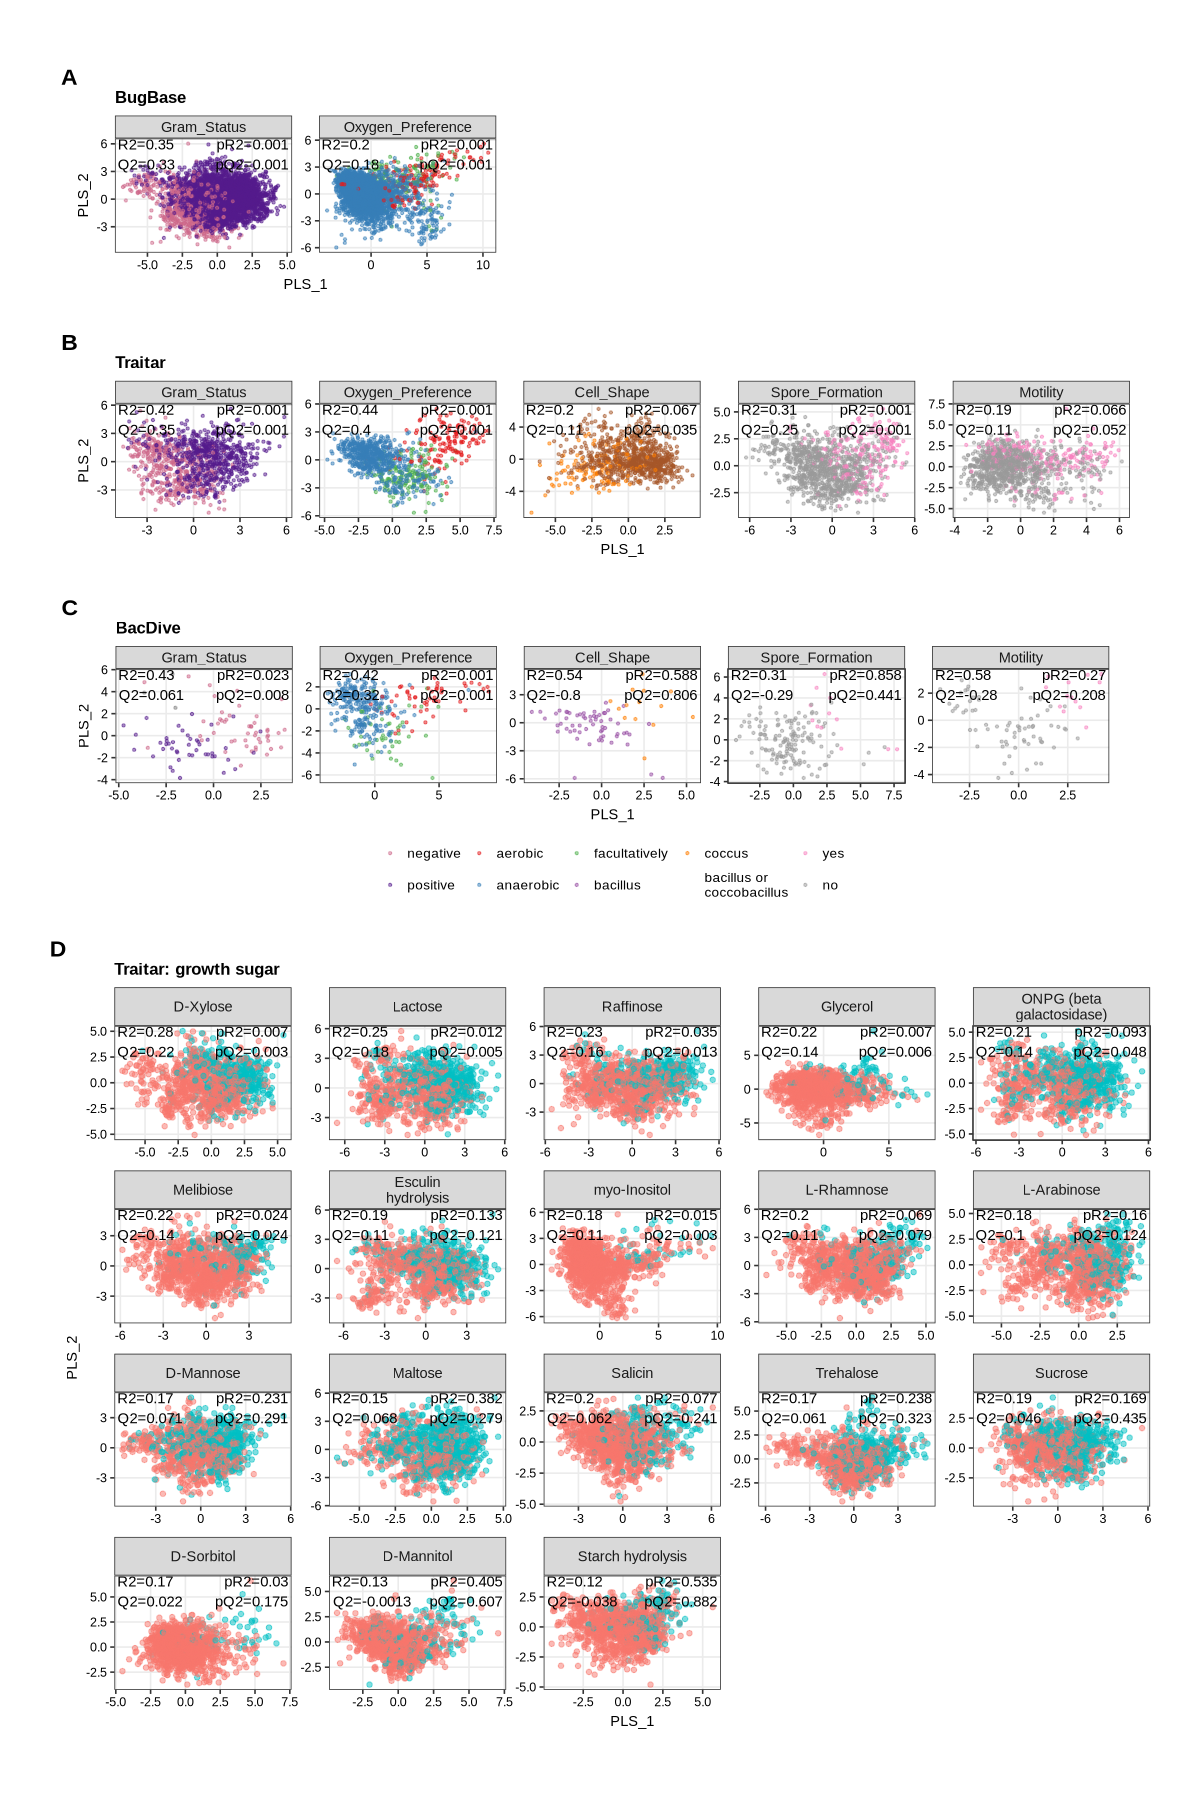

In [80]:
local({
  options(repr.plot.width = 8, repr.plot.height = 12, repr.plot.res = 150)
  print(figS5_1)
})


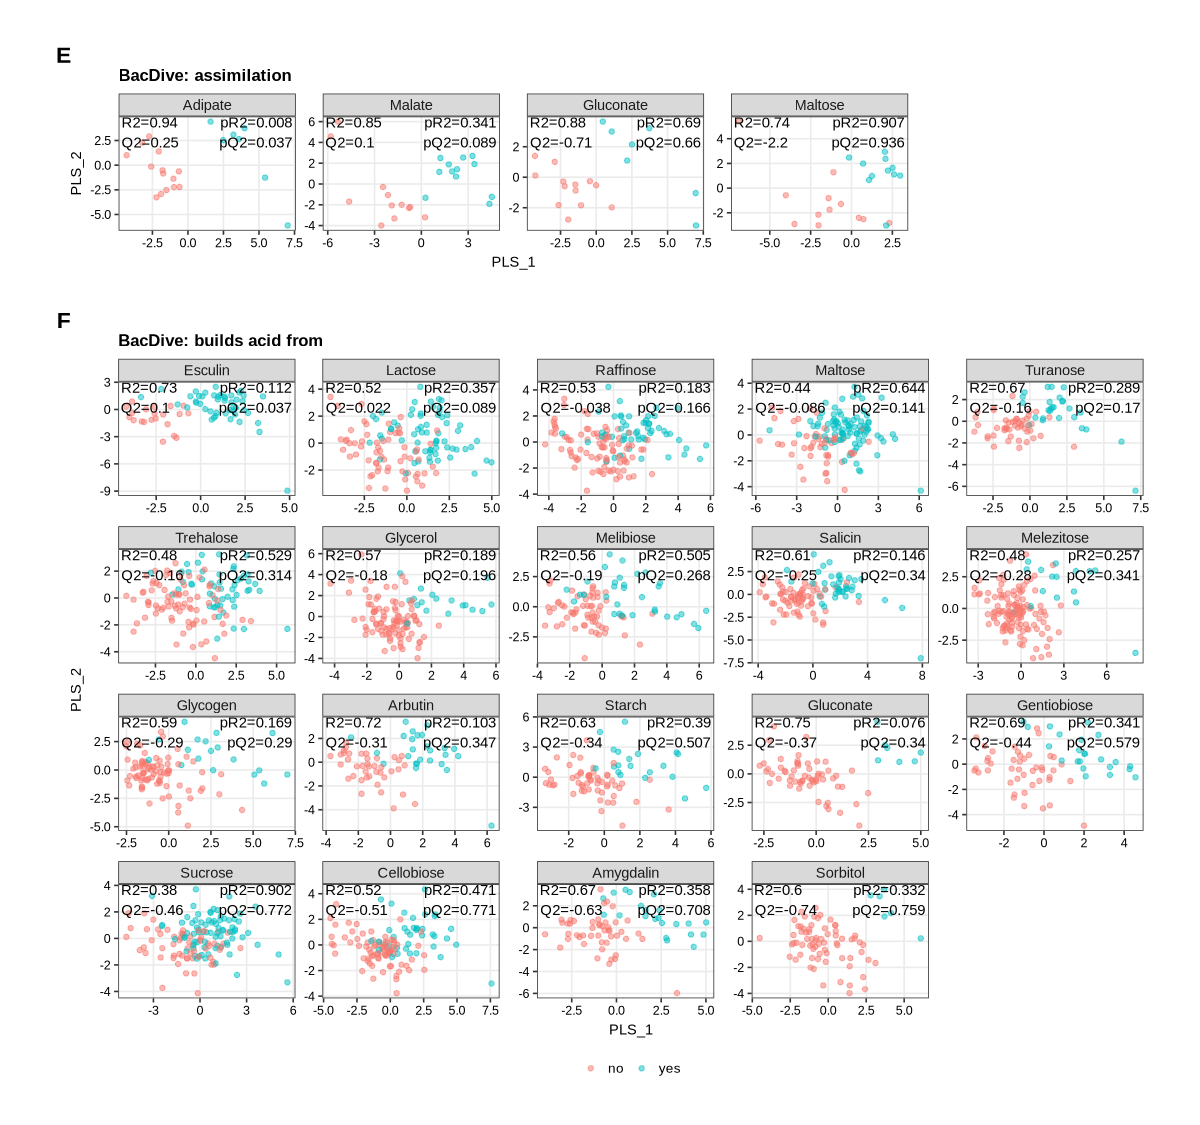

In [81]:
local({
  options(repr.plot.width = 8, repr.plot.height = 7.5, repr.plot.res = 150)
  print(figS5_2)
})
